# HW13 - токенизация текста, инференс готовой модели и fine-tuning для классификации

In [1]:
import copy
import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from datasets import disable_progress_bar, load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    pipeline,
)
from transformers.utils import logging as hf_logging

SEED = 42
DATASET_NAME = 'emotion'
READY_MODEL_NAME = 'distilbert-base-uncased-finetuned-sst-2-english'
MODEL_NAME = 'google/bert_uncased_L-2_H-128_A-2'
TRAIN_SIZE = 2000
VAL_SIZE = 500
TEST_SIZE = 500
MAX_LENGTH = 64
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
EPOCHS = 8
LEARNING_RATE = 2e-4


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / 'homeworks').exists() and (candidate / 'pyproject.toml').exists():
            return candidate
    raise RuntimeError('Repository root not found')


REPO_ROOT = find_repo_root(Path.cwd())
HW_DIR = REPO_ROOT / 'homeworks' / 'HW13'
ARTIFACTS_DIR = HW_DIR / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
disable_progress_bar()
hf_logging.set_verbosity_error()

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Python: {sys.version.split()[0]}')
print(f'Device: {device}')
print(f'Artifacts dir: {ARTIFACTS_DIR}')


/Users/hilez/institute-of-ai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.12.7
Device: cpu
Artifacts dir: /Users/hilez/institute-of-ai/homeworks/HW13/artifacts


## 1. Данные и первичный анализ

Выбран датасет `emotion`. Он хорошо подходит для учебного fine-tuning:
- задача уже оформлена как текстовая классификация;
- в датасете 6 понятных классов;
- тексты короткие, поэтому пайплайн легко воспроизводится на CPU.


In [2]:
raw = load_dataset(DATASET_NAME)
label_names = raw['train'].features['label'].names

train_raw = raw['train'].shuffle(seed=SEED).select(range(TRAIN_SIZE))
val_raw = raw['validation'].shuffle(seed=SEED).select(range(VAL_SIZE))
test_raw = raw['test'].shuffle(seed=SEED).select(range(TEST_SIZE))

train_df = train_raw.to_pandas()
val_df = val_raw.to_pandas()
test_df = test_raw.to_pandas()

for df in (train_df, val_df, test_df):
    df['label_name'] = df['label'].map(lambda idx: label_names[idx])

print('Label names:', label_names)
print('Split sizes:', {'train': len(train_df), 'validation': len(val_df), 'test': len(test_df)})

length_stats = pd.concat([
    train_df['text'].str.split().str.len(),
    val_df['text'].str.split().str.len(),
    test_df['text'].str.split().str.len(),
], ignore_index=True).describe(percentiles=[0.95]).round(2)

print('\nText length in words:')
display(length_stats.to_frame(name='value'))

class_distribution = pd.DataFrame({
    'train': train_df['label_name'].value_counts().reindex(label_names),
    'validation': val_df['label_name'].value_counts().reindex(label_names),
    'test': test_df['label_name'].value_counts().reindex(label_names),
})
print('\nClass distribution:')
display(class_distribution)

analysis_rows = []
for label_idx, label_name in enumerate(label_names):
    row = train_df[train_df['label'] == label_idx].iloc[0]
    analysis_rows.append({'true_emotion': label_name, 'text': row['text']})
analysis_df = pd.DataFrame(analysis_rows)

print('\nExamples from the dataset:')
display(analysis_df)


Label names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Split sizes: {'train': 2000, 'validation': 500, 'test': 500}

Text length in words:


,value
count,3000.00
mean,19.18
std,10.95
min,2.00
50%,17.00
95%,41.00
max,62.00



Class distribution:


,train,validation,test
label_name,,,
sadness,598,134,144
joy,663,176,193
love,161,50,30
anger,261,71,64
fear,247,50,54
surprise,70,19,15



Examples from the dataset:


,true_emotion,text
0,sadness,i am in no way complaining or whining or feeli...
1,joy,i had pocket qq and was feeling pretty confide...
2,love,im not going to lie some days i feel uber supp...
3,anger,i feel a bit stressed because it feels like im...
4,fear,while cycling in the country
5,surprise,i tell the people closest to me things that i ...


## 2. Токенизация

Для fine-tuning используется компактная BERT-модель `google/bert_uncased_L-2_H-128_A-2`.
Ниже показано, как текст превращается в `tokens`, `input_ids` и `attention_mask`, а также отдельно демонстрируются `padding` и `truncation`.


In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

special_tokens = {
    'cls_token': tokenizer.cls_token,
    'sep_token': tokenizer.sep_token,
    'pad_token': tokenizer.pad_token,
    'unk_token': tokenizer.unk_token,
    'mask_token': tokenizer.mask_token,
}
print('Special tokens:', special_tokens)


def summarize_encoding(text: str) -> dict:
    encoded = tokenizer(text, add_special_tokens=True)
    return {
        'text': text,
        'tokens': tokenizer.convert_ids_to_tokens(encoded['input_ids']),
        'input_ids': encoded['input_ids'],
        'attention_mask': encoded['attention_mask'],
    }


tokenization_examples = pd.DataFrame(
    [summarize_encoding(text) for text in analysis_df['text'].head(5)]
)
display(tokenization_examples)

padding_demo = tokenizer(
    analysis_df['text'].head(2).tolist(),
    padding='max_length',
    truncation=True,
    max_length=12,
)
padding_demo_df = pd.DataFrame({
    'text': analysis_df['text'].head(2).tolist(),
    'input_ids': padding_demo['input_ids'],
    'attention_mask': padding_demo['attention_mask'],
    'decoded': [tokenizer.decode(ids) for ids in padding_demo['input_ids']],
})

print('Padding / truncation demo with max_length=12:')
display(padding_demo_df)


Special tokens: {'cls_token': '[CLS]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'unk_token': '[UNK]', 'mask_token': '[MASK]'}


,text,tokens,input_ids,attention_mask
0,i am in no way complaining or whining or feeli...,"[[CLS], i, am, in, no, way, complaining, or, w...","[101, 1045, 2572, 1999, 2053, 2126, 17949, 203...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,i had pocket qq and was feeling pretty confide...,"[[CLS], i, had, pocket, q, ##q, and, was, feel...","[101, 1045, 2018, 4979, 1053, 4160, 1998, 2001...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
2,im not going to lie some days i feel uber supp...,"[[CLS], im, not, going, to, lie, some, days, i...","[101, 10047, 2025, 2183, 2000, 4682, 2070, 242...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,i feel a bit stressed because it feels like im...,"[[CLS], i, feel, a, bit, stressed, because, it...","[101, 1045, 2514, 1037, 2978, 13233, 2138, 200...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,while cycling in the country,"[[CLS], while, cycling, in, the, country, [SEP]]","[101, 2096, 9670, 1999, 1996, 2406, 102]","[1, 1, 1, 1, 1, 1, 1]"


Padding / truncation demo with max_length=12:


,text,input_ids,attention_mask,decoded
0,i am in no way complaining or whining or feeli...,"[101, 1045, 2572, 1999, 2053, 2126, 17949, 203...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",[CLS] i am in no way complaining or whining [SEP]
1,i had pocket qq and was feeling pretty confide...,"[101, 1045, 2018, 4979, 1053, 4160, 1998, 2001...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",[CLS] i had pocket qq and was feeling pretty c...


## 3. Инференс готовой pretrained-модели

В качестве готовой модели для быстрого инференса используется `distilbert-base-uncased-finetuned-sst-2-english`.
Данная бинарная sentiment-модель полезна как sanity-check, но напрямую не совпадает с 6-классовой задачей `emotion`.


In [4]:
ready_clf = pipeline('text-classification', model=READY_MODEL_NAME)
ready_outputs = ready_clf(analysis_df['text'].tolist())

analysis_df['predicted_sentiment'] = [item['label'] for item in ready_outputs]
analysis_df['sentiment_score'] = [round(float(item['score']), 4) for item in ready_outputs]

print('Ready-model inference on one example per emotion class:')
display(analysis_df)

print(
    'Комментарий: готовая sentiment-модель различает общий позитив/негатив, '
    'но теряет нюансы между sadness / anger / fear / surprise / love.'
)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 9453.59it/s]

Ready-model inference on one example per emotion class:


,true_emotion,text,predicted_sentiment,sentiment_score
0,sadness,i am in no way complaining or whining or feeli...,POSITIVE,0.9552
1,joy,i had pocket qq and was feeling pretty confide...,POSITIVE,0.9998
2,love,im not going to lie some days i feel uber supp...,NEGATIVE,0.9761
3,anger,i feel a bit stressed because it feels like im...,NEGATIVE,0.9978
4,fear,while cycling in the country,POSITIVE,0.9969
5,surprise,i tell the people closest to me things that i ...,NEGATIVE,0.6197


Комментарий: готовая sentiment-модель различает общий позитив/негатив, но теряет нюансы между sadness / anger / fear / surprise / love.


## 4. Fine-tuning для классификации текста

Ниже реализован полный пайплайн fine-tuning:
- токенизация датасета;
- `DataLoader` c динамическим padding;
- обучение по эпохам;
- каждая эпоха рассматривается как кандидат на лучший вариант;
- после обучения строится таблица `validation_results_df`, и лучший вариант выбирается по `validation f1_macro` с tie-break по `val_loss`.



In [5]:
def tokenize_batch(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)


train_ds = train_raw.rename_column('label', 'labels').map(tokenize_batch, batched=True)
val_ds = val_raw.rename_column('label', 'labels').map(tokenize_batch, batched=True)
test_ds = test_raw.rename_column('label', 'labels').map(tokenize_batch, batched=True)

for ds in (train_ds, val_ds, test_ds):
    ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

collator = DataCollatorWithPadding(tokenizer=tokenizer)
train_loader = DataLoader(train_ds, batch_size=TRAIN_BATCH_SIZE, shuffle=True, collate_fn=collator)
val_loader = DataLoader(val_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, collate_fn=collator)
test_loader = DataLoader(test_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, collate_fn=collator)


def evaluate_model(model, loader):
    model.eval()
    losses = []
    preds = []
    true = []
    probs = []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            losses.append(float(outputs.loss.item()))
            logits = outputs.logits
            batch_probs = torch.softmax(logits, dim=-1)
            preds.extend(logits.argmax(dim=-1).cpu().numpy().tolist())
            true.extend(batch['labels'].cpu().numpy().tolist())
            probs.extend(batch_probs.cpu().numpy().tolist())
    return {
        'loss': float(np.mean(losses)),
        'accuracy': float(accuracy_score(true, preds)),
        'f1_macro': float(f1_score(true, preds, average='macro')),
        'preds': preds,
        'true': true,
        'probs': probs,
    }


Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 39/39 [00:00<00:00, 8415.80it/s]

Model selection metric: val_f1_macro
Validation candidates sorted by quality:


,epoch,train_loss,val_loss,val_accuracy,val_f1_macro
0,6,0.141634,0.601573,0.842,0.816218
1,5,0.206805,0.591201,0.832,0.809392
2,7,0.102395,0.722618,0.820,0.806223
3,4,0.353296,0.559337,0.826,0.792667
4,3,0.589926,0.615613,0.822,0.784027
5,8,0.087200,0.736370,0.806,0.778662
6,2,1.074088,0.843563,0.766,0.720173
7,1,1.567894,1.364378,0.568,0.336995


Selected best variant by validation:


,epoch,train_loss,val_loss,val_accuracy,val_f1_macro
0,6.0,0.141634,0.601573,0.842,0.816218


Chosen checkpoint: epoch=6, val_f1_macro=0.8162, val_loss=0.6016


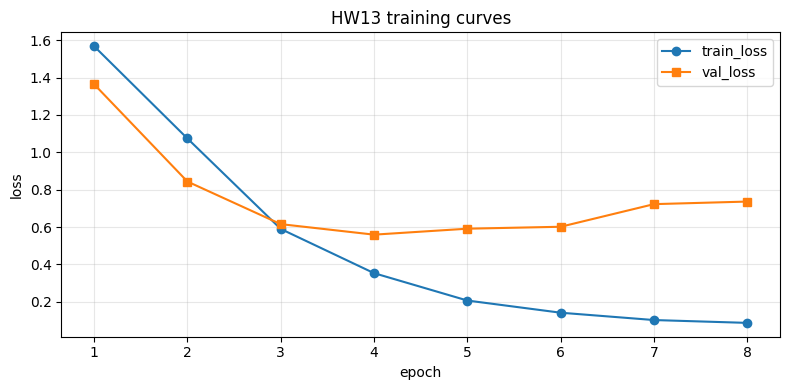

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(label_names))
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

history = []
epoch_state_dicts = {}
MODEL_SELECTION_METRIC = 'val_f1_macro'

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_losses.append(float(loss.item()))

    val_metrics = evaluate_model(model, val_loader)
    row = {
        'epoch': epoch,
        'train_loss': float(np.mean(train_losses)),
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
        'val_f1_macro': val_metrics['f1_macro'],
    }
    history.append(row)
    epoch_state_dicts[epoch] = copy.deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})

history_df = pd.DataFrame(history)
validation_results_df = (
    history_df[['epoch', 'train_loss', 'val_loss', 'val_accuracy', 'val_f1_macro']]
    .sort_values([MODEL_SELECTION_METRIC, 'val_loss'], ascending=[False, True])
    .reset_index(drop=True)
)
best_validation_variant = validation_results_df.iloc[0].to_dict()
best_epoch = int(best_validation_variant['epoch'])
best_val_score = float(best_validation_variant[MODEL_SELECTION_METRIC])
best_state = epoch_state_dicts[best_epoch]

print(f'Model selection metric: {MODEL_SELECTION_METRIC}')
print('Validation candidates sorted by quality:')
display(validation_results_df)
print('Selected best variant by validation:')
display(pd.DataFrame([best_validation_variant]))
print(
    f"Chosen checkpoint: epoch={best_epoch}, "
    f"val_f1_macro={best_val_score:.4f}, val_loss={best_validation_variant['val_loss']:.4f}"
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train_loss')
ax.plot(history_df['epoch'], history_df['val_loss'], marker='s', label='val_loss')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_title('HW13 training curves')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)



## 5. Финальная оценка на test и анализ ошибок

После выбора лучшей эпохи по `validation` модель оценивается на `test` ровно один раз.
В этой секции сохраняются обязательные артефакты:
- `artifacts/confusion_matrix.png`
- `artifacts/sample_predictions.csv`


Final evaluation uses the checkpoint selected on validation:


,selection_metric,selected_epoch,best_validation_f1_macro,test_accuracy,test_f1_macro
0,val_f1_macro,6,0.8162,0.856,0.7952


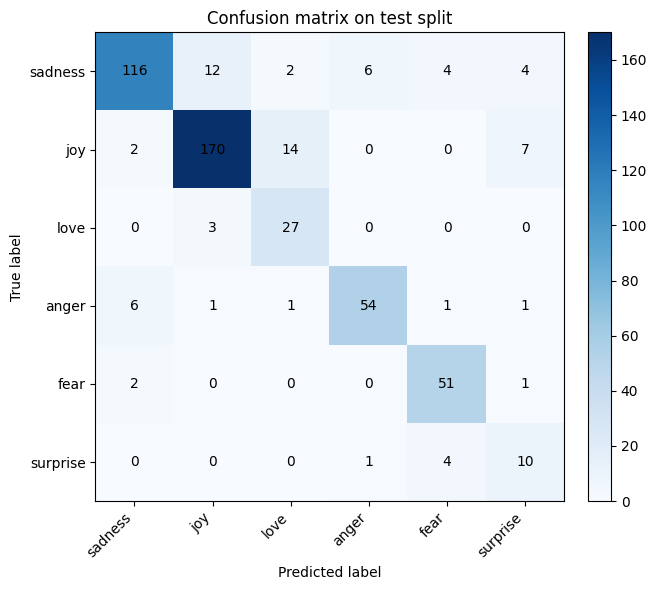

Prediction examples:


,text,true_label,pred_label,confidence
0,i feel i can only hope im not alone in these t...,sadness,joy,0.985781
1,i cant write a review for a book i adore unles...,love,joy,0.985482
2,i think im making up for feeling like i missed...,sadness,joy,0.985138
3,i feel and talk like a disadvantaged child and...,sadness,joy,0.983497
4,i was playing a sport in an advanced pe class ...,anger,joy,0.982954
5,i had my carrot sticks not on the program they...,sadness,joy,0.982730
6,i don t feel comfortable playing games with th...,joy,sadness,0.982719
7,i am feeling rather heartless because i recent...,anger,sadness,0.981908
8,i didnt make it to my weight watchers meeting ...,sadness,joy,0.981029
9,when i learnt that my best friend had failed t...,anger,sadness,0.977413


Most confident errors:


,text,true_label,pred_label,confidence
20,i feel i can only hope im not alone in these t...,sadness,joy,0.985781
13,i cant write a review for a book i adore unles...,love,joy,0.985482
436,i think im making up for feeling like i missed...,sadness,joy,0.985138
30,i feel and talk like a disadvantaged child and...,sadness,joy,0.983497
320,i was playing a sport in an advanced pe class ...,anger,joy,0.982954
422,i had my carrot sticks not on the program they...,sadness,joy,0.982730
103,i don t feel comfortable playing games with th...,joy,sadness,0.982719
412,i am feeling rather heartless because i recent...,anger,sadness,0.981908
48,i didnt make it to my weight watchers meeting ...,sadness,joy,0.981029
260,when i learnt that my best friend had failed t...,anger,sadness,0.977413


Top confusions:


,true_label,pred_label,count
8,joy,love,14
1,sadness,joy,12
11,joy,surprise,7
18,anger,sadness,6
3,sadness,anger,6
5,sadness,surprise,4
4,sadness,fear,4
34,surprise,fear,4
13,love,joy,3
6,joy,sadness,2


Saved artifacts:
/Users/hilez/institute-of-ai/homeworks/HW13/artifacts/sample_predictions.csv
/Users/hilez/institute-of-ai/homeworks/HW13/artifacts/confusion_matrix.png


In [7]:
if best_state is None:
    raise RuntimeError('Best state was not captured during training')

model.load_state_dict(best_state)
model.to(device)

test_metrics = evaluate_model(model, test_loader)

selection_and_test_df = pd.DataFrame([
    {
        'selection_metric': MODEL_SELECTION_METRIC,
        'selected_epoch': best_epoch,
        'best_validation_f1_macro': round(best_val_score, 4),
        'test_accuracy': round(test_metrics['accuracy'], 4),
        'test_f1_macro': round(test_metrics['f1_macro'], 4),
    }
])
print('Final evaluation uses the checkpoint selected on validation:')
display(selection_and_test_df)

cm = confusion_matrix(test_metrics['true'], test_metrics['preds'])
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=45, ha='right')
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion matrix on test split')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

results_df = test_df[['text', 'label_name']].rename(columns={'label_name': 'true_label'}).copy()
results_df['pred_label'] = [label_names[idx] for idx in test_metrics['preds']]
results_df['confidence'] = [float(max(prob_vector)) for prob_vector in test_metrics['probs']]
results_df['is_error'] = results_df['true_label'] != results_df['pred_label']

errors_df = results_df[results_df['is_error']].sort_values('confidence', ascending=False)
correct_df = results_df[~results_df['is_error']].sort_values('confidence', ascending=False)

sample_predictions_df = pd.concat([
    errors_df.head(10),
    correct_df.head(10),
], ignore_index=True)[['text', 'true_label', 'pred_label', 'confidence']]
sample_predictions_df.to_csv(ARTIFACTS_DIR / 'sample_predictions.csv', index=False)

print('Prediction examples:')
display(sample_predictions_df.head(10))

print('Most confident errors:')
display(errors_df[['text', 'true_label', 'pred_label', 'confidence']].head(10))

top_confusions = (
    pd.DataFrame(cm, index=label_names, columns=label_names)
    .stack()
    .reset_index(name='count')
    .rename(columns={'level_0': 'true_label', 'level_1': 'pred_label'})
    .query('true_label != pred_label and count > 0')
    .sort_values('count', ascending=False)
)
print('Top confusions:')
display(top_confusions.head(10))

print('Saved artifacts:')
print(ARTIFACTS_DIR / 'sample_predictions.csv')
print(ARTIFACTS_DIR / 'confusion_matrix.png')



## 6. Краткий вывод

- Разбор токенизации показывает, как BERT получает специальные токены, `input_ids` и `attention_mask`.
- Готовая sentiment-модель полезна только как быстрый sanity-check, она не совпадает с 6-классовой постановкой `emotion`.
- После fine-tuning компактная BERT-модель заметно лучше согласуется с задачей и даёт устойчивые метрики на `test`.
